# 09 — Ferramenta versus chats comerciais

Comparação entre resultados da ferramenta/API e chats comerciais.

In [1]:
# Configuração comum dos estudos integrados
from pathlib import Path
import re
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.22

ARTEFATOS = {
    'unificado': 'result_unificado_final.xlsx',
    'ferramenta': 'result_ferramenta_final.xlsx',
    'chats': 'result_chats_final.xlsx',
}

PASTAS_PROVAVEIS = [
    Path('../artefatos'),
    Path('../../artefatos'),
    Path('artefatos'),
    Path('../'),
    Path('.'),
    Path('/mnt/data'),
]

def encontra_arquivo(nome):
    for pasta in PASTAS_PROVAVEIS:
        caminho = pasta / nome
        if caminho.exists():
            return caminho.resolve()
    raise FileNotFoundError(
        f'Arquivo não encontrado: {nome}. Coloque os artefatos em ../artefatos/, artefatos/ ou na mesma pasta do notebook.'
    )

NOMES_MODELOS = {
    'claude-haiku-4-5': 'Claude Haiku',
    'claude-opus-4-7': 'Claude Opus',
    'claude-sonnet-4-6': 'Claude Sonnet',
    'deepseek-v4-flash': 'DeepSeek Flash',
    'deepseek-v4-pro': 'DeepSeek Pro',
    'gpt-4o-mini': 'GPT 4o mini',
    'gpt-5.4': 'GPT 5.4',
    'gpt-5.4-mini': 'GPT 5.4 mini',
    'gpt-5.5': 'GPT 5.5',
    'std_chatgpt': 'ChatGPT comercial',
    'std_claude': 'Claude comercial',
}

def provedor(modelo):
    m = str(modelo).lower()
    if 'claude' in m:
        return 'Anthropic'
    if 'gpt' in m or 'chatgpt' in m:
        return 'OpenAI'
    if 'deepseek' in m:
        return 'DeepSeek'
    return 'Outro'

def prepara(df, origem_padrao=None):
    """Cria campos de leitura do TCC em memória. Não salva nenhuma base intermediária."""
    df = df.copy()
    if 'origem_resultado' not in df.columns:
        df['origem_resultado'] = origem_padrao or 'nao_informada'
    for col in [
        'avaliacao_final', 'concisao_score', 'avaliacao_gpt', 'avaliacao_opus',
        'avaliacao_humana', 'resposta_tokens_tiktoken', 'input_tokens', 'output_tokens',
        'custo_estimado_usd', 'n_invocacoes', 'latencia_s'
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].replace('nao pertinente', np.nan), errors='coerce')
    if 'convergencia' in df.columns:
        df['convergencia'] = df['convergencia'].astype(bool)
    else:
        df['convergencia'] = np.nan
    df['acerto'] = df['avaliacao_final']
    df['resposta_direta'] = df['concisao_score']
    df['discordancia_avaliadores'] = ~df['convergencia']
    df['origem_legivel'] = df['origem_resultado'].map({
        'ferramenta': 'Ferramenta',
        'chat_comercial': 'Chat comercial'
    }).fillna(df['origem_resultado'])
    df['modelo_legivel'] = df['modelo'].map(NOMES_MODELOS).fillna(df['modelo'])
    df['provedor'] = df['modelo'].map(provedor)
    df['status_acerto'] = pd.cut(
        df['acerto'], bins=[-0.01, 0.01, 0.99, 1.01],
        labels=['Incorreta', 'Parcial', 'Correta']
    )
    df['acerto_total'] = (df['acerto'] == 1).astype(int)
    df['erro_total'] = (df['acerto'] == 0).astype(int)
    df['parcial'] = (df['acerto'] == 0.5).astype(int)
    df['nao_totalmente_correta'] = (df['acerto'] < 1).astype(int)
    return df

def ler_artefatos():
    caminhos = {k: encontra_arquivo(v) for k, v in ARTEFATOS.items()}
    df_unificado = prepara(pd.read_excel(caminhos['unificado']))
    df_ferramenta = prepara(pd.read_excel(caminhos['ferramenta']), 'ferramenta')
    df_chats = prepara(pd.read_excel(caminhos['chats']), 'chat_comercial')
    return caminhos, df_unificado, df_ferramenta, df_chats

caminhos, df, df_ferramenta, df_chats = ler_artefatos()
print('Artefatos lidos:')
for nome, caminho in caminhos.items():
    print(f'- {nome}: {caminho}')
print(f'Base unificada: {df.shape[0]} linhas x {df.shape[1]} colunas')

# Ordem padrão dos modelos: maior acerto médio primeiro.
ORDEM_MODELOS = (
    df.groupby('modelo_legivel')['acerto']
      .mean()
      .sort_values(ascending=False)
      .index
      .tolist()
)

def pct(x):
    if pd.isna(x):
        return ''
    return f'{100*x:.1f}%'

def dinheiro(x):
    if pd.isna(x):
        return ''
    return f'US$ {x:.5f}'

def resumo_metricas(data, grupo):
    g = data.groupby(grupo, observed=True)
    out = g.agg(
        n=('acerto', 'size'),
        acerto_medio=('acerto', 'mean'),
        taxa_correta=('acerto_total', 'mean'),
        taxa_parcial=('parcial', 'mean'),
        taxa_incorreta=('erro_total', 'mean'),
        resposta_direta=('resposta_direta', 'mean'),
        discordancia=('discordancia_avaliadores', 'mean'),
        tokens_resposta=('resposta_tokens_tiktoken', 'mean'),
    ).reset_index()
    return out

def ordena_por_modelo(series_or_df, col=None):
    if isinstance(series_or_df, pd.Series):
        return series_or_df.reindex([m for m in ORDEM_MODELOS if m in series_or_df.index])
    return series_or_df.set_index(col).reindex([m for m in ORDEM_MODELOS if m in series_or_df[col].values]).reset_index()

def barh_series(s, titulo, xlabel='', percentual=False, figsize=(8, 5), limite=None):
    s = s.dropna().copy()
    if limite is not None:
        s = s.sort_values(ascending=False).head(limite)
    else:
        s = s.sort_values(ascending=True)
    vals = s * 100 if percentual else s
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(vals.index.astype(str), vals.values)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()

def bar_series(s, titulo, xlabel='', ylabel='', percentual=False, figsize=(8, 4), rot=0):
    s = s.dropna().copy()
    vals = s * 100 if percentual else s
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(vals.index.astype(str), vals.values)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=rot)
    ax.grid(axis='x', visible=False)
    plt.tight_layout()
    plt.show()

def stacked_percent(data, index_col, column_col, titulo, ordem_colunas=None, figsize=(9, 6)):
    tab = pd.crosstab(data[index_col], data[column_col], normalize='index')
    if ordem_colunas:
        tab = tab.reindex(columns=[c for c in ordem_colunas if c in tab.columns])
    tab = tab.loc[tab.sum(axis=1).sort_values().index]
    ax = (tab * 100).plot(kind='barh', stacked=True, figsize=figsize)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel('% das respostas')
    ax.set_ylabel('')
    ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()
    return tab

def heatmap_tabela(pivot, titulo, formato='.1f', percentual=True, figsize=(9, 5)):
    dados = pivot.copy()
    valores = dados.values * 100 if percentual else dados.values
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(valores, aspect='auto')
    ax.set_title(titulo, loc='left')
    ax.set_xticks(np.arange(dados.shape[1]))
    ax.set_xticklabels(dados.columns.astype(str), rotation=35, ha='right')
    ax.set_yticks(np.arange(dados.shape[0]))
    ax.set_yticklabels(dados.index.astype(str))
    # Só anota quando a matriz é pequena o suficiente para não virar poluição visual.
    if dados.shape[0] * dados.shape[1] <= 80:
        for i in range(dados.shape[0]):
            for j in range(dados.shape[1]):
                val = valores[i, j]
                if not np.isnan(val):
                    texto = f'{val:{formato}}' + ('%' if percentual else '')
                    ax.text(j, i, texto, ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    plt.tight_layout()
    plt.show()

def boxplot_por_grupo(data, valor, grupo, titulo, ylabel='', figsize=(9, 5), ordem=None):
    base = data[[valor, grupo]].dropna()
    if ordem is None:
        ordem = base.groupby(grupo)[valor].median().sort_values().index.tolist()
    grupos = [base.loc[base[grupo] == g, valor].values for g in ordem if g in base[grupo].unique()]
    labels = [g for g in ordem if g in base[grupo].unique()]
    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot(grupos, labels=labels, vert=False, showfliers=False)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(ylabel or valor)
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

def tabela_formatada(data, percent_cols=None, money_cols=None, round_cols=None, n=20):
    out = data.copy().head(n)
    percent_cols = percent_cols or []
    money_cols = money_cols or []
    round_cols = round_cols or []
    for c in percent_cols:
        if c in out.columns:
            out[c] = out[c].map(pct)
    for c in money_cols:
        if c in out.columns:
            out[c] = out[c].map(dinheiro)
    for c in round_cols:
        if c in out.columns:
            out[c] = out[c].round(3)
    display(out)

def texto_curto(s, n=180):
    if pd.isna(s):
        return ''
    s = re.sub(r'\s+', ' ', str(s)).strip()
    return s if len(s) <= n else s[:n-1] + '…'

Artefatos lidos:
- unificado: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_unificado_final.xlsx
- ferramenta: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_ferramenta_final.xlsx
- chats: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_chats_final.xlsx
Base unificada: 1650 linhas x 34 colunas


## Pergunta do estudo
A ferramenta entrega desempenho comparável aos chats comerciais?

,origem_legivel,n,acerto,correta,direta,discordancia,tokens
0,Ferramenta,1350,95.5%,91.9%,69.3%,6.8%,205.719
1,Chat comercial,300,91.3%,85.7%,54.3%,9.7%,321.257


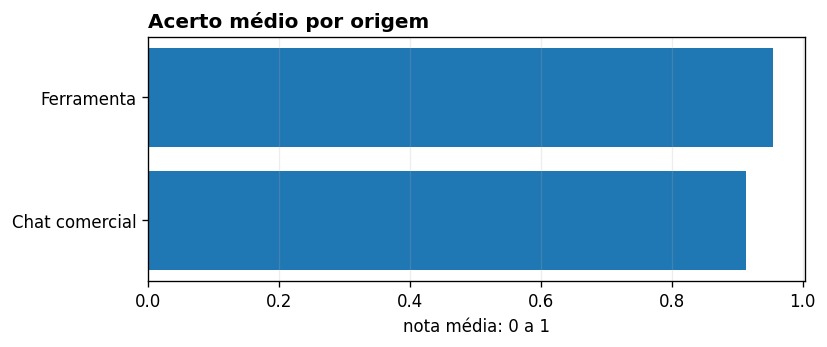

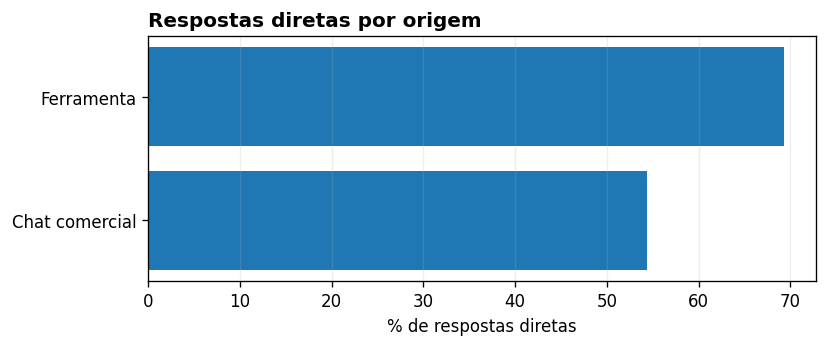

In [2]:
origem = df.groupby('origem_legivel').agg(
    n=('acerto','size'),
    acerto=('acerto','mean'),
    correta=('acerto_total','mean'),
    direta=('resposta_direta','mean'),
    discordancia=('discordancia_avaliadores','mean'),
    tokens=('resposta_tokens_tiktoken','mean')
).sort_values('acerto', ascending=False)
tabela_formatada(origem.reset_index(), percent_cols=['acerto','correta','direta','discordancia'], round_cols=['tokens'], n=10)
barh_series(origem['acerto'].sort_values(), 'Acerto médio por origem', 'nota média: 0 a 1', figsize=(7, 3))
barh_series(origem['direta'].sort_values(), 'Respostas diretas por origem', '% de respostas diretas', percentual=True, figsize=(7, 3))

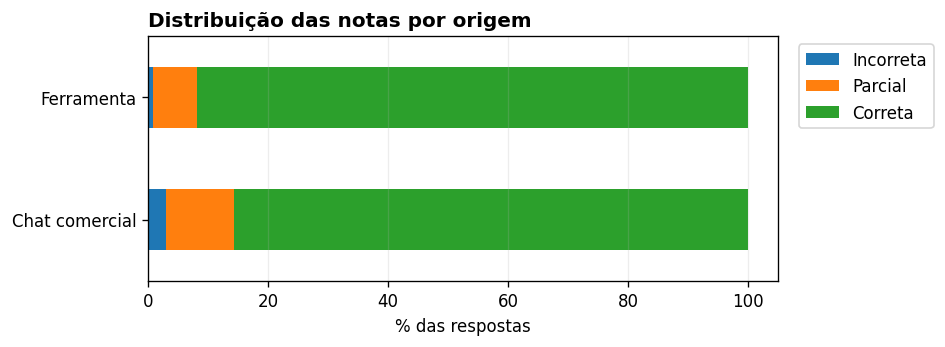

status_acerto,Incorreta,Parcial,Correta
origem_legivel,,,
Chat comercial,0.030000,0.113333,0.856667
Ferramenta,0.008148,0.073333,0.918519


In [3]:
stacked_percent(df, 'origem_legivel', 'status_acerto', 'Distribuição das notas por origem', ordem_colunas=['Incorreta','Parcial','Correta'], figsize=(8, 3))

,origem_legivel,modelo_legivel,acerto,direta,n
1,Chat comercial,Claude comercial,0.950000,0.086667,150
0,Chat comercial,ChatGPT comercial,0.876667,1.000000,150
10,Ferramenta,GPT 5.5,0.996667,0.973333,150
3,Ferramenta,Claude Opus,0.976667,0.486667,150
4,Ferramenta,Claude Sonnet,0.973333,0.360000,150
5,Ferramenta,DeepSeek Flash,0.970000,0.560000,150
6,Ferramenta,DeepSeek Pro,0.963333,0.473333,150
8,Ferramenta,GPT 5.4,0.963333,0.973333,150
2,Ferramenta,Claude Haiku,0.936667,0.533333,150
7,Ferramenta,GPT 4o mini,0.910000,0.886667,150


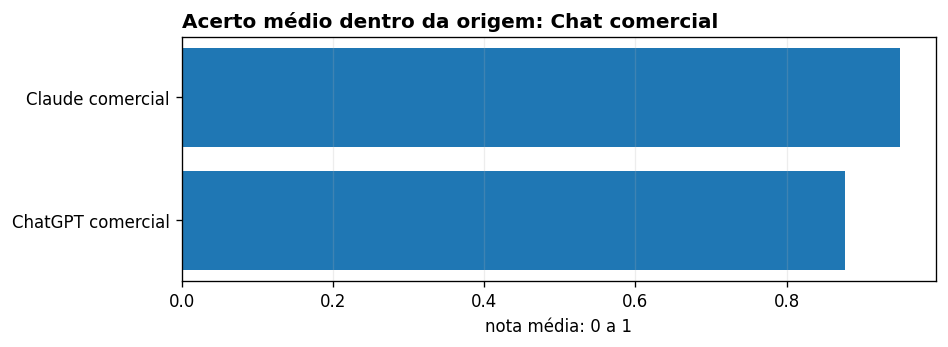

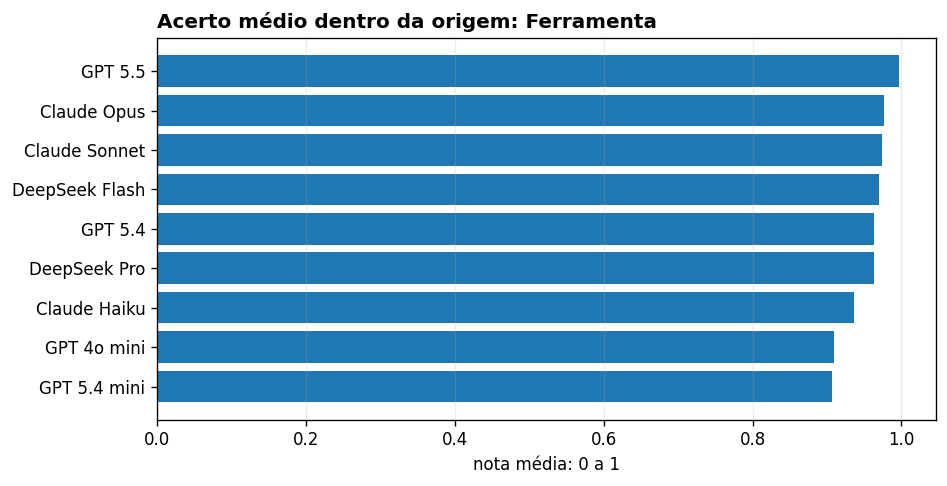

In [4]:
modelo_origem = df.groupby(['origem_legivel','modelo_legivel']).agg(acerto=('acerto','mean'), direta=('resposta_direta','mean'), n=('acerto','size')).reset_index()
display(modelo_origem.sort_values(['origem_legivel','acerto'], ascending=[True,False]))
for origem_nome, sub in modelo_origem.groupby('origem_legivel'):
    s = sub.set_index('modelo_legivel')['acerto'].sort_values()
    barh_series(s, f'Acerto médio dentro da origem: {origem_nome}', 'nota média: 0 a 1', figsize=(8, max(3, 0.35*len(s)+1)))

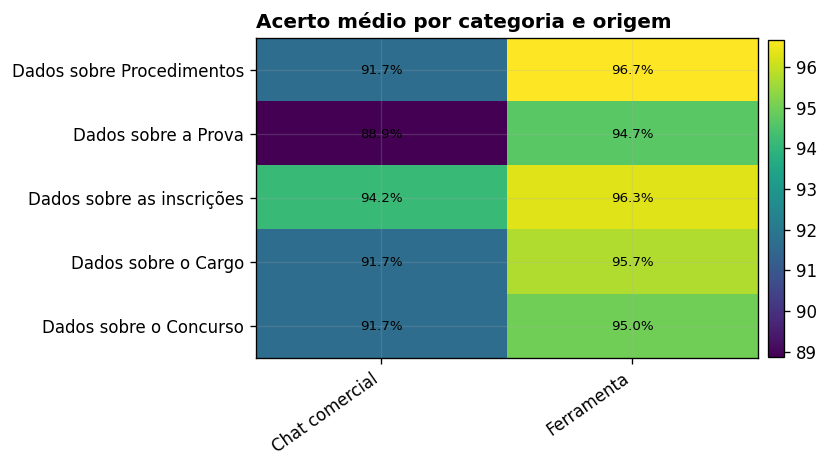

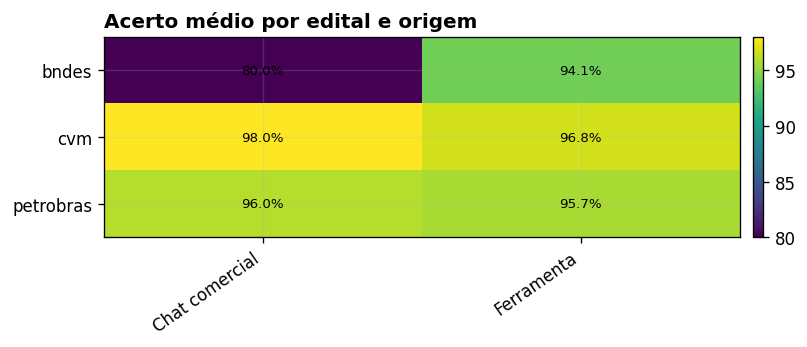

In [5]:
pivot = df.pivot_table(index='categoria', columns='origem_legivel', values='acerto', aggfunc='mean')
heatmap_tabela(pivot, 'Acerto médio por categoria e origem', formato='.1f', percentual=True, figsize=(7, 4))
pivot = df.pivot_table(index='edital', columns='origem_legivel', values='acerto', aggfunc='mean')
heatmap_tabela(pivot, 'Acerto médio por edital e origem', formato='.1f', percentual=True, figsize=(7, 3))

In [6]:
# Comparação pareada por pergunta: média dos modelos de cada origem para o mesmo edital/id.
por_pergunta = df.groupby(['edital','id','categoria','origem_legivel']).agg(
    acerto=('acerto','mean'),
    direta=('resposta_direta','mean'),
    tokens=('resposta_tokens_tiktoken','mean')
).reset_index()
par = por_pergunta.pivot_table(index=['edital','id','categoria'], columns='origem_legivel', values=['acerto','direta','tokens'])
par.columns = [f'{a}_{b}'.replace(' ', '_').lower() for a,b in par.columns]
par = par.reset_index()
if {'acerto_ferramenta','acerto_chat_comercial'}.issubset(par.columns):
    par['dif_acerto_ferramenta_menos_chat'] = par['acerto_ferramenta'] - par['acerto_chat_comercial']

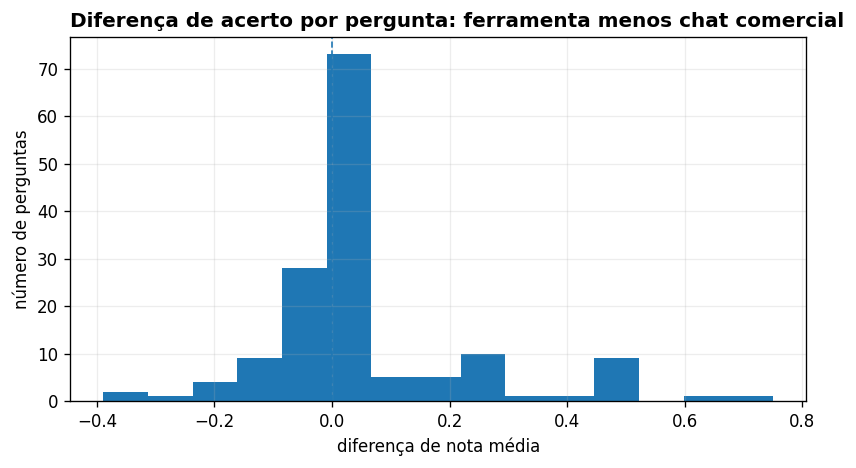

,edital,id,categoria,acerto_ferramenta,acerto_chat_comercial,dif_acerto_ferramenta_menos_chat
74,cvm,25,Dados sobre o Cargo,0.611111,1.00,-0.388889
116,petrobras,17,Dados sobre o Concurso,0.666667,1.00,-0.333333
99,cvm,50,Dados sobre Procedimentos,0.722222,1.00,-0.277778
73,cvm,24,Dados sobre o Cargo,0.777778,1.00,-0.222222
4,bndes,5,Dados sobre as inscrições,0.833333,1.00,-0.166667
128,petrobras,29,Dados sobre o Cargo,0.833333,1.00,-0.166667
140,petrobras,41,Dados sobre a Prova,0.833333,1.00,-0.166667
36,bndes,37,Dados sobre a Prova,0.611111,0.75,-0.138889
75,cvm,26,Dados sobre o Cargo,0.888889,1.00,-0.111111
66,cvm,17,Dados sobre o Concurso,0.888889,1.00,-0.111111


,edital,id,categoria,acerto_ferramenta,acerto_chat_comercial,dif_acerto_ferramenta_menos_chat
20,bndes,21,Dados sobre o Cargo,1.000000,0.25,0.750000
44,bndes,45,Dados sobre a Prova,0.888889,0.25,0.638889
17,bndes,18,Dados sobre o Cargo,1.000000,0.50,0.500000
42,bndes,43,Dados sobre a Prova,1.000000,0.50,0.500000
34,bndes,35,Dados sobre a Prova,1.000000,0.50,0.500000
14,bndes,15,Dados sobre o Concurso,1.000000,0.50,0.500000
112,petrobras,13,Dados sobre o Concurso,1.000000,0.50,0.500000
104,petrobras,5,Dados sobre as inscrições,1.000000,0.50,0.500000
49,bndes,50,Dados sobre Procedimentos,1.000000,0.50,0.500000
46,bndes,47,Dados sobre Procedimentos,1.000000,0.50,0.500000


In [7]:
# Histograma manual para a diferença pareada, sem criar legenda sobre o gráfico.
if 'dif_acerto_ferramenta_menos_chat' in par.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(par['dif_acerto_ferramenta_menos_chat'].dropna(), bins=15)
    ax.axvline(0, linestyle='--', linewidth=1)
    ax.set_title('Diferença de acerto por pergunta: ferramenta menos chat comercial', loc='left')
    ax.set_xlabel('diferença de nota média')
    ax.set_ylabel('número de perguntas')
    plt.tight_layout()
    plt.show()
    display(par[['edital','id','categoria','acerto_ferramenta','acerto_chat_comercial','dif_acerto_ferramenta_menos_chat']].sort_values('dif_acerto_ferramenta_menos_chat').head(15))
    display(par[['edital','id','categoria','acerto_ferramenta','acerto_chat_comercial','dif_acerto_ferramenta_menos_chat']].sort_values('dif_acerto_ferramenta_menos_chat', ascending=False).head(15))

,origem_legivel,provedor,acerto,direta,n
0,Chat comercial,Anthropic,0.950000,0.086667,150
2,Ferramenta,Anthropic,0.962222,0.460000,450
3,Ferramenta,DeepSeek,0.966667,0.516667,300
1,Chat comercial,OpenAI,0.876667,1.000000,150
4,Ferramenta,OpenAI,0.944167,0.956667,600


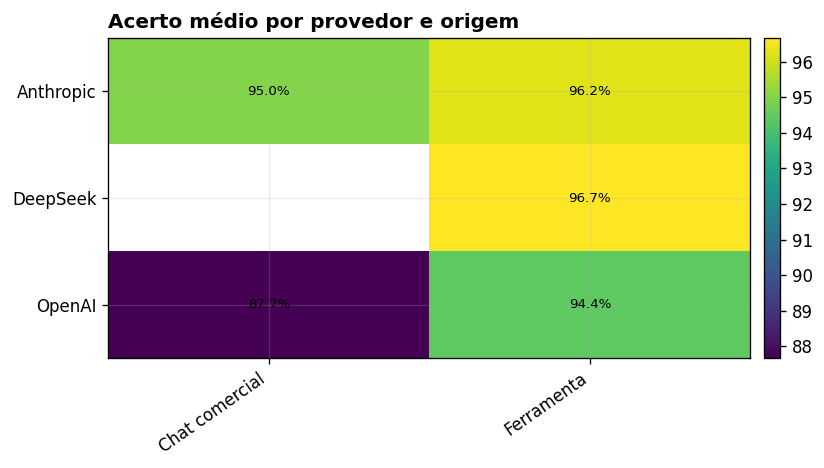

In [8]:
# Comparação por provedor e origem, quando há modelos do mesmo provedor nas duas origens.
prov = df.groupby(['origem_legivel','provedor']).agg(acerto=('acerto','mean'), direta=('resposta_direta','mean'), n=('acerto','size')).reset_index()
display(prov.sort_values(['provedor','origem_legivel']))
pivot = prov.pivot(index='provedor', columns='origem_legivel', values='acerto')
heatmap_tabela(pivot, 'Acerto médio por provedor e origem', formato='.1f', percentual=True, figsize=(7, 4))